# MolmoAct2 LoRA fine-tuning workshop (AMD, ROCm)

This notebook takes a **pretrained MolmoAct2** vision-language-action model and **LoRA fine-tunes** it, then runs the fine-tuned policy in the **interactive LIBERO simulator** - all on AMD hardware (a single Strix Halo iGPU, or a multi-GPU AMD Instinct node).

**Real -> sim story.** We start from `allenai/MolmoAct2-DROID` (trained on the *real* Franka Panda arm, delta end-effector control) and LoRA-adapt it onto the `allenai/MolmoAct2-LIBERO-Dataset` (the LIBERO *simulator*). Same Panda embodiment and action space, so the base is well-initialized; the LoRA adapter learns the sim.

**How LoRA works here.** The heavy VLM backbone (SigLIP2 vision tower + Qwen3-class LM) is *frozen*; small low-rank adapter matrices are trained on top. The flow-matching action expert stays fully trainable (upstream found this crucial). This keeps memory low enough to fine-tune on a single Strix Halo.

Steps:
1. **Model import smoke-test** - ROCm/GPU sanity + import the MolmoAct2 stacks
2. **Download + load** the base checkpoint (one real forward proves the load)
3. **Open-loop rollout** on a few real DROID episodes (GT-vs-pred overlay)
4. **LoRA fine-tune** setup + a few steps (auto-scales single/multi-GPU)
5. **Load the LoRA checkpoint on the DROID base -> LIBERO policy** + closed-loop eval
6. **Interactive sim** in the browser (synchronous chunk replay: plan -> act -> plan)

Everything is **self-contained in this notebook** - steps 1-3 (probe, load, open-loop) run directly *in the kernel* (no external scripts), and the fine-tune / eval / interactive-sim cells build their exact command inline. ROCm's noisy `HIPBLAS`/experimental-attention warnings are suppressed so the output stays readable.

This runs on a single Strix Halo iGPU; the sibling `finetune_molmoact2_cluster.ipynb` retargets step 4 to a multi-GPU AMD Instinct node.

In [1]:
import os

# --- Quiet ROCm/torch on this iGPU *before* importing torch --------------------------------
# On gfx1151 every matmul otherwise logs "HIPBLAS_STATUS_NOT_SUPPORTED ... will attempt to
# recover by calling cublas" and "experimental flash/mem-efficient attention" UserWarnings,
# which flood the notebook. Preferring plain hipBLAS over hipBLASLt stops the fallback spam
# at the source; PYTHONWARNINGS + filterwarnings hide the rest (in-kernel and in children).
os.environ.setdefault("TORCH_BLAS_PREFER_HIPBLASLT", "0")
os.environ.setdefault("PYTHONWARNINGS", "ignore")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
# Silence the per-file download bars (file-003.parquet 100% ...) and the tqdm train/eval/load
# loops that otherwise redraw every fraction of a second and swamp the cell output. Progress is
# instead reported by the loaders' own periodic log lines (and the loss plot in Step 4).
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TQDM_DISABLE", "1")

import sys, re, json, glob, time, subprocess, signal, logging, warnings
warnings.filterwarnings("ignore")
# Silence per-request HTTP logs and the base loader's benign bf16-patch "needle not found"
# notices so the only thing printed is the workshop's own progress.
for _n in ("transformers", "lerobot", "accelerate", "datasets", "huggingface_hub",
           "httpx", "httpcore", "urllib3", "host_server_droid"):
    logging.getLogger(_n).setLevel(logging.ERROR)

import numpy as np
import torch

# Paths inside the workshop image. Everything below runs in THIS kernel's trainable venv;
# the few genuine subprocesses left (fine-tune / eval / RT sim server) build their exact
# command inline in the cell, so there are no hidden wrapper scripts to go hunting for.
RYZERS    = "/ryzers"
DROID_SRV = os.environ.get("DROID_SERVER_DIR", "/repos/molmoact2/examples/droid")
TRAIN_PY  = "/opt/train-venv/bin/python"
OUT_DIR   = os.environ.get("OUT_DIR", "/outputs")
os.makedirs(OUT_DIR, exist_ok=True)
if DROID_SRV not in sys.path:
    sys.path.insert(0, DROID_SRV)

# Env for child processes: keep the warning-suppression flags and DROP the inherited
# matplotlib-inline backend (MPLBACKEND=module://matplotlib_inline...), which crashes
# headless children (the open-loop / eval crash we hit before).
def child_env(**extra):
    e = dict(os.environ)
    e.pop("MPLBACKEND", None)
    e.update({"TORCH_BLAS_PREFER_HIPBLASLT": "0", "PYTHONWARNINGS": "ignore",
              "PYTHONUNBUFFERED": "1"})
    e.update({k: str(v) for k, v in extra.items()})
    return e

# Backstop line filter: even with the flags above, drop any stray ROCm/torch warning lines
# so the streamed subprocess output stays readable.
_NOISE = ("UserWarning", "HIPBLAS_STATUS", "hipblasLtMatmul", "Triggered internally",
          "scaled_dot_product_attention", "run_backward", "aotriton", "AOTRITON")

def run_cmd(cmd, env=None, cwd=None, quiet_warnings=True):
    """Stream a subprocess into the notebook, filtering the noisy warning lines."""
    print("$ " + (cmd if isinstance(cmd, str) else " ".join(map(str, cmd))) + "\n", flush=True)
    p = subprocess.Popen(cmd, shell=isinstance(cmd, str), env=env, cwd=cwd,
                         stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in p.stdout:
        if quiet_warnings and any(tok in line for tok in _NOISE):
            continue
        print(line, end="", flush=True)
    p.wait()
    if p.returncode != 0:
        raise RuntimeError(f"command failed (exit {p.returncode})")

# LeRobot logs one metrics line per `log_freq` steps, e.g. "step:10 ... loss:1.684 grdn:.. lr:..".
# run_train streams the process (filtering noise like run_cmd) AND scrapes those (step, loss)
# points so Step 4 can draw a small loss curve at the end. Handles the human-formatted step
# number (10, 1.5K, 2M) that LeRobot prints for large runs.
_STEP_RE = re.compile(r"\bstep:\s*([0-9.]+)\s*([KMB]?)")
_LOSS_RE = re.compile(r"\bloss:\s*([0-9.]+)")
_SUF = {"": 1.0, "K": 1e3, "M": 1e6, "B": 1e9}

def run_train(cmd, env=None, cwd=None):
    """Stream a training subprocess (noise-filtered) and return captured [(step, loss), ...]."""
    print("$ " + (cmd if isinstance(cmd, str) else " ".join(map(str, cmd))) + "\n", flush=True)
    p = subprocess.Popen(cmd, shell=isinstance(cmd, str), env=env, cwd=cwd,
                         stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    pts = []
    for line in p.stdout:
        if any(tok in line for tok in _NOISE):
            continue
        print(line, end="", flush=True)
        ms, ml = _STEP_RE.search(line), _LOSS_RE.search(line)
        if ms and ml:
            pts.append((float(ms.group(1)) * _SUF[ms.group(2)], float(ml.group(1))))
    p.wait()
    if p.returncode != 0:
        raise RuntimeError(f"command failed (exit {p.returncode})")
    return pts

# Flow-matching action-head call, tolerant of the inference_action_mode (new) vs action_mode
# (old) kwarg rename across MolmoAct2 checkpoints. Ported inline so Steps 2-3 need no scripts.
def predict_chunk(policy, norm_tag, images, task, state, num_steps):
    kw = dict(processor=policy.processor, images=images, task=task, state=state,
              norm_tag=norm_tag, enable_depth_reasoning=False, num_steps=num_steps,
              normalize_language=True, enable_cuda_graph=False)
    try:
        out = policy.model.predict_action(inference_action_mode="continuous", **kw)
    except TypeError as e:
        if "action_mode" not in str(e):
            raise
        out = policy.model.predict_action(action_mode="continuous", **kw)
    raw = out.actions if hasattr(out, "actions") else out
    if torch.is_tensor(raw):
        raw = raw.detach().to(dtype=torch.float32, device="cpu").numpy()
    a = np.asarray(raw, dtype=np.float32)
    if a.ndim == 3 and a.shape[0] == 1:
        a = a[0]
    return a

## 1. Model import smoke-test

Confirms the trainable venv sees a ROCm device and imports the LeRobot MolmoAct2 training stack (torch+HIP, transformers, lerobot, robosuite/mujoco). The detected **GPU count** drives sensible defaults below (small batch/steps on a single Strix Halo, larger on a multi-GPU Instinct node). No weights are loaded here - this is a fast import/environment check.

In [2]:
# In-kernel probe (no subprocess): confirm a ROCm device and that the trainable MolmoAct2
# + sim stack imports. The detected GPU count drives the batch/step defaults below.
assert torch.version.hip, "torch is not a ROCm build"
assert torch.cuda.is_available(), "no ROCm device visible (check /dev/kfd, /dev/dri)"
print(f"torch            : {torch.__version__}  hip={torch.version.hip}")

N_GPUS, gpu_names, vram_gib = max(1, torch.cuda.device_count()), [], []
for i in range(torch.cuda.device_count()):
    pr = torch.cuda.get_device_properties(i)
    gpu_names.append(pr.name); vram_gib.append(round(pr.total_memory / 1024**3, 1))
    print(f"device[{i}]        : {pr.name}  ({vram_gib[-1]} GiB)")

for mod in ("lerobot", "transformers", "robosuite", "mujoco", "accelerate"):
    m = __import__(mod)
    print(f"{mod:16s} : {getattr(m, '__version__', '?')}")

print(f"\n==> detected {N_GPUS} GPU(s): {gpu_names}  VRAM(GiB)={vram_gib}")

torch            : 2.10.0+rocm7.2.2.git23d69b29  hip=7.2.53211
device[0]        : Radeon 8060S Graphics  (47.0 GiB)
lerobot          : 0.5.2


[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /opt/venv/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


transformers     : 5.5.4
robosuite        : 1.4.0
mujoco           : 3.3.2
accelerate       : 1.14.0

==> detected 1 GPU(s): ['Radeon 8060S Graphics']  VRAM(GiB)=[47.0]


## 2. Download + load the base checkpoint

Downloads the base checkpoint to adapt (`allenai/MolmoAct2-DROID`, real Franka) and the fine-tuning dataset (`allenai/MolmoAct2-LIBERO-Dataset`) into the persistent HF cache, then **loads the checkpoint and runs one real forward** to prove the whole flow-matching action path executes on ROCm (bf16). Nothing is re-hosted by us; everything pulls from Hugging Face at run time. Set `HF_TOKEN` for faster/gated downloads. First run pulls tens of GB - it is cached and reused afterwards.

**One base, used twice (and why the on-disk sizes differ).** This exact same `allenai/MolmoAct2-DROID` download is reused for *both* the open-loop check (Step 3, loaded here) *and* as the starting point of the LoRA fine-tune (Step 4 passes `--policy.checkpoint_path=allenai/MolmoAct2-DROID`) - it is fetched once and shared from the HF cache. The released base ships in **fp32** (~22 GB across 5 shards ≈ 4 bytes × 5.4B params). We load it and train in **bf16**, and LeRobot saves the fine-tuned policy - the base with the LoRA update folded in - as a single **bf16** `model.safetensors` (~11.5 GB ≈ 2 bytes × 5.4B params) plus tiny normalizer stats. So the fine-tuned checkpoint is *half* the size not because it has fewer weights, but because it is stored at half the precision.

In [3]:
from huggingface_hub import snapshot_download

BASE_CKPT    = os.environ.get("BASE_CKPT", "allenai/MolmoAct2-DROID")
DATASET_REPO = os.environ.get("DATASET_REPO", "allenai/MolmoAct2-LIBERO-Dataset")

# Pull straight from Hugging Face into the mounted HF cache (nothing is re-hosted by us).
# Cached + reused on later runs; first run pulls tens of GB. Set HF_TOKEN for gated/faster pulls.
def prefetch(repo_id, repo_type, tries=5):
    for n in range(1, tries + 1):
        try:
            snapshot_download(repo_id=repo_id, repo_type=repo_type)
            print(f"    cached [{repo_type}]: {repo_id}")
            return
        except Exception as e:
            print(f"    ({repo_type} {repo_id} attempt {n}/{tries} failed: {str(e)[:100]}; resuming...)")
            if n == tries:
                raise
            time.sleep(5)

prefetch(BASE_CKPT, "model")
prefetch(DATASET_REPO, "dataset")
print("PASS: base checkpoint + dataset cached")

    cached [model]: allenai/MolmoAct2-DROID
    cached [dataset]: allenai/MolmoAct2-LIBERO-Dataset
PASS: base checkpoint + dataset cached


In [4]:
# Load the base checkpoint in THIS kernel via the upstream DROID Policy loader (bf16 patches
# baked at /repos/molmoact2/examples/droid) and run ONE real forward. Proves the full 6B
# flow-matching action path executes on ROCm and that the just-downloaded weights load. First
# call may JIT-compile kernels (slow once). We keep `base_policy` around to reuse in Step 3.
from PIL import Image
from host_server_droid import Policy, NORM_TAG

DTYPE = {"bfloat16": torch.bfloat16, "float16": torch.float16,
         "float32": torch.float32}[os.environ.get("DTYPE", "bfloat16")]
NUM_STEPS = int(os.environ.get("NUM_STEPS", "10"))

t0 = time.time()
base_policy = Policy(repo_id=BASE_CKPT, device="cuda:0", dtype=DTYPE)
n_params = sum(p.numel() for p in base_policy.model.parameters())
print(f"model loaded     : {time.time()-t0:.1f}s  params={n_params/1e9:.2f}B  norm_tag={NORM_TAG}")

# One dummy DROID observation: 3 cams (ext1, ext2, wrist) + 8-DoF state.
imgs = [Image.fromarray(np.random.randint(0, 255, (180, 320, 3), dtype=np.uint8)) for _ in range(3)]
t1 = time.time()
acts = predict_chunk(base_policy, NORM_TAG, imgs, "pick up the object", np.zeros(8, np.float32), NUM_STEPS)
print(f"predict_action   : {acts.shape}  in {(time.time()-t1)*1000:.0f} ms")
assert acts.ndim == 2 and acts.shape[-1] == 8 and np.isfinite(acts).all(), f"bad actions {acts.shape}"
print("PASS: MolmoAct2 full-model ROCm smoke OK")

2026-07-18 01:17:43,173 [INFO] Resolved snapshot dir: /root/.cache/huggingface/hub/models--allenai--MolmoAct2-DROID/snapshots/d8c1abd8a27d8e859455bbe514df2bcc617db0fb
2026-07-18 01:17:43,174 [WARNING] patch patched_bf16_dtype: needle not found in /root/.cache/huggingface/hub/models--allenai--MolmoAct2-DROID/snapshots/d8c1abd8a27d8e859455bbe514df2bcc617db0fb/modeling_molmoact2.py
2026-07-18 01:17:43,174 [WARNING] patch patched_bf16_to_array: needle not found in /root/.cache/huggingface/hub/models--allenai--MolmoAct2-DROID/snapshots/d8c1abd8a27d8e859455bbe514df2bcc617db0fb/modeling_molmoact2.py
2026-07-18 01:17:43,175 [WARNING] patch patched_bf16_dtype: needle not found in /root/.cache/huggingface/modules/transformers_modules/d8c1abd8a27d8e859455bbe514df2bcc617db0fb/modeling_molmoact2.py
2026-07-18 01:17:43,175 [WARNING] patch patched_bf16_to_array: needle not found in /root/.cache/huggingface/modules/transformers_modules/d8c1abd8a27d8e859455bbe514df2bcc617db0fb/modeling_molmoact2.py
202

model loaded     : 8.5s  params=5.44B  norm_tag=franka_droid
predict_action   : (15, 8)  in 2701 ms
PASS: MolmoAct2 full-model ROCm smoke OK


## 3. Open-loop rollout on a few real DROID episodes

Before fine-tuning, sanity-check the base policy on the **real** data it was trained on. This is a multi-episode port-fidelity check: we draw **`N_DROID_EPISODES` random episodes** (default `2`) from `allenai/MolmoAct2-DROID-Dataset` - each is a *different* real teleop episode with its own task string - and replay each one open-loop (receding-horizon: replan every `STRIDE` steps). For every episode we write, under `/outputs`:

- `droid_ep<E>.mp4` - the episode's exterior camera view (the scene the model predicts on),
- `droid_ep<E>_actions.png` - the 8-DoF **GT (teleop) vs predicted** action trajectory, overlaid per dim on the same axes (GT solid, pred dashed).

**About the downloads you see.** MolmoAct2 consumes **3 camera streams** (`exterior_1`, `exterior_2`, `wrist`), so each random episode pulls its own 3 camera `.mp4` clips (plus one small `.parquet` of states/actions) on demand from the Hub. That is why you see downloads continue per episode, and why - mid-run - the file count can be ahead of the finished-episode count (e.g. the 3rd clip of episode 2 is still streaming while only episode 1 has printed its metrics). It is **bounded**: total clips ≈ `3 × N_DROID_EPISODES`, and everything is cached for reruns. This is *not* the closed-loop task benchmark (that's Step 5); to make it lighter set `N_DROID_EPISODES=1`, or pin one episode with `EPISODE=<id>`.

The newest episode's plot + video are shown inline below.

2026-07-18 01:18:10,138 [INFO] generated new fontManager
2026-07-18 01:18:10,548 [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


episode 9090  task='Hang the towel on the white stand.'  length=309
open-loop        : L1=0.1435 MSE=0.0662  (947 ms/infer)


2026-07-18 01:23:58,706 [WARNING] IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (320, 180) to (320, 192) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


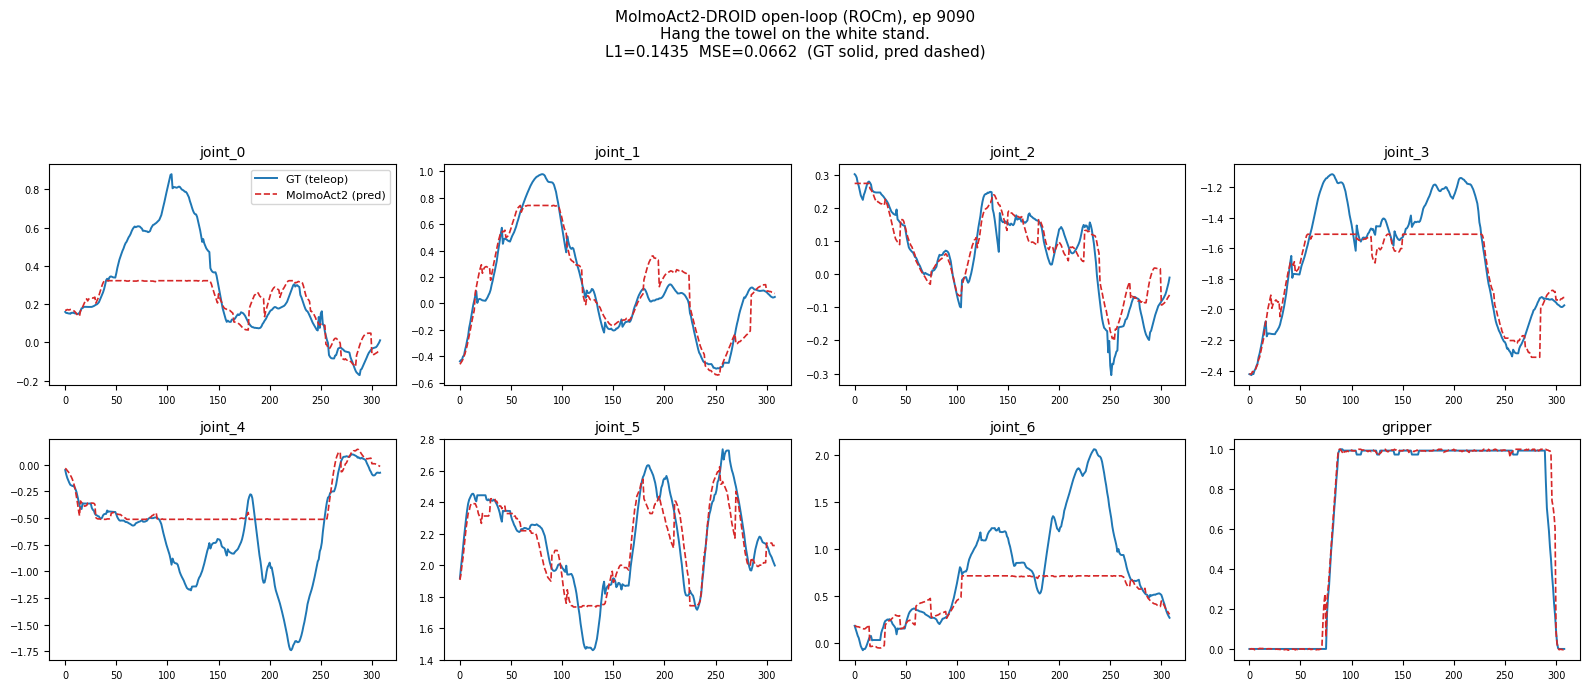

episode 2550  task='Pick up the plate on the right and pour its contents into the plate on the left'  length=498
open-loop        : L1=0.0982 MSE=0.0756  (989 ms/infer)


2026-07-18 01:30:50,293 [WARNING] IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (320, 180) to (320, 192) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


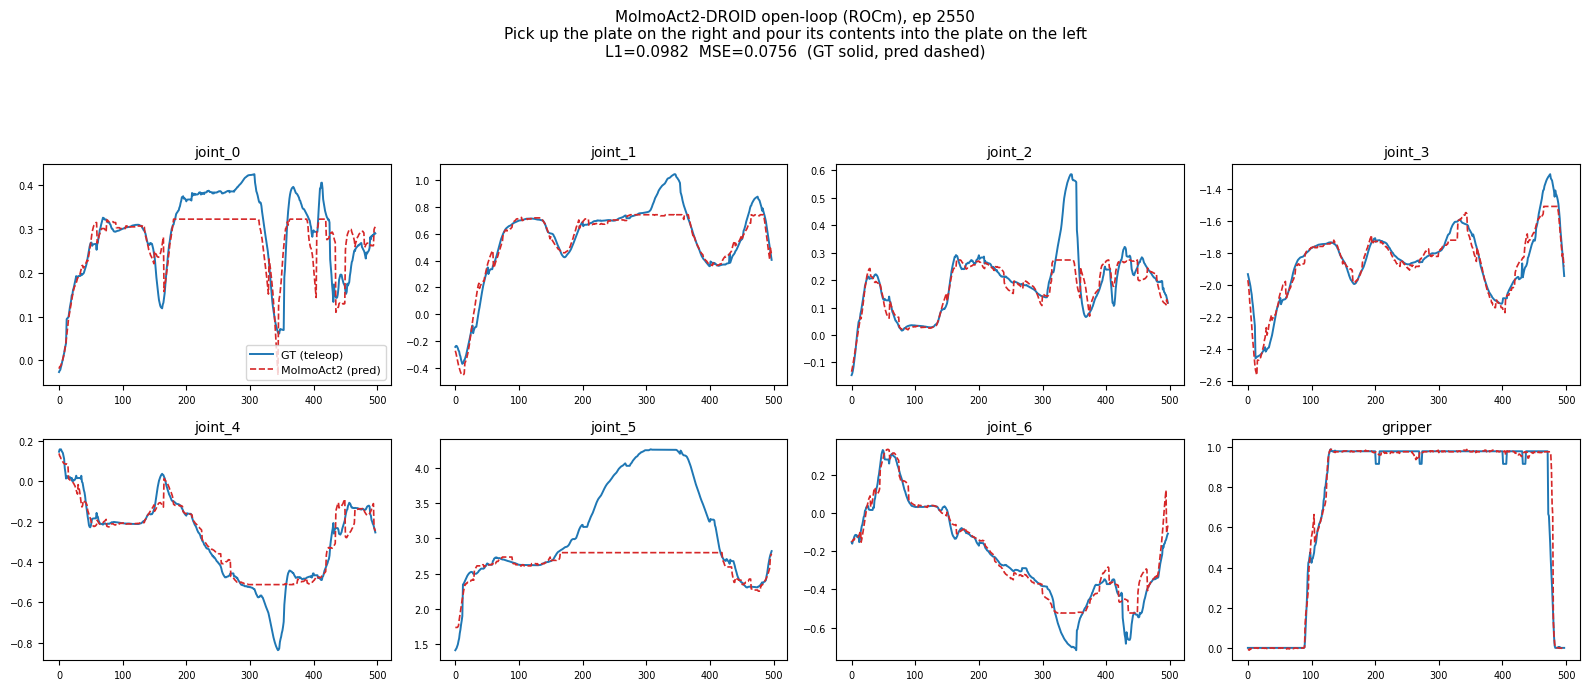

In [5]:
import random
import pyarrow.parquet as pq
import pyarrow.compute as pc
from huggingface_hub import hf_hub_download
from IPython.display import Video, display
import matplotlib.pyplot as plt  # inline backend -> plots render in the notebook, no Agg/subprocess

EVAL_REPO = os.environ.get("EVAL_REPO", "allenai/MolmoAct2-DROID-Dataset")
STRIDE    = int(os.environ.get("STRIDE", "15"))
N_DROID   = int(os.environ.get("N_DROID_EPISODES", "2"))
VIEW_CAM  = "observation.images." + os.environ.get("CAM", "exterior_1_left")
CAMS = ["observation.images.exterior_1_left", "observation.images.exterior_2_left",
        "observation.images.wrist_left"]
DIM_NAMES = ["joint_0", "joint_1", "joint_2", "joint_3", "joint_4", "joint_5", "joint_6", "gripper"]

def _grab_frames(path, indices):
    """Decode the specific source frames we replan on (nearest-match fallback)."""
    import av
    want = sorted(set(int(i) for i in indices))
    if not want:
        return {}
    container = av.open(path); stream = container.streams.video[0]; stream.thread_type = "AUTO"
    rate, tb = float(stream.average_rate), stream.time_base
    try:
        container.seek(max(int((want[0] / rate) / tb), 0), stream=stream, backward=True, any_frame=False)
    except Exception:
        container.seek(0)
    out, remaining = {}, set(want)
    for frame in container.decode(stream):
        if frame.pts is None:
            continue
        idx = int(round(float(frame.pts * tb) * rate))
        if idx in remaining:
            out[idx] = frame.to_ndarray(format="rgb24"); remaining.discard(idx)
        elif idx > want[-1]:
            break
        if not remaining:
            break
    container.close()
    if remaining and out:
        got = sorted(out)
        for idx in list(remaining):
            out[idx] = out[min(got, key=lambda g: abs(g - idx))]
    return out

def _decode_clip(path, start_idx, n_frames):
    """Decode n contiguous frames from start_idx for the episode video."""
    import av
    container = av.open(path); stream = container.streams.video[0]; stream.thread_type = "AUTO"
    rate, tb = float(stream.average_rate), stream.time_base
    try:
        container.seek(max(int((start_idx / rate) / tb), 0), stream=stream, backward=True, any_frame=False)
    except Exception:
        container.seek(0)
    frames = []
    for frame in container.decode(stream):
        if frame.pts is None:
            continue
        if int(round(float(frame.pts * tb) * rate)) < start_idx:
            continue
        frames.append(frame.to_ndarray(format="rgb24"))
        if len(frames) >= n_frames:
            break
    container.close()
    return frames

def run_openloop_episode():
    """Replay one random DROID episode open-loop (replan every STRIDE) and show GT-vs-pred."""
    info = json.load(open(hf_hub_download(EVAL_REPO, "meta/info.json", repo_type="dataset")))
    fps, data_tmpl, video_tmpl = info["fps"], info["data_path"], info["video_path"]
    meta_ep = pq.read_table(hf_hub_download(
        EVAL_REPO, "meta/episodes/chunk-000/file-000.parquet", repo_type="dataset")).to_pydict()
    episodes = list(meta_ep["episode_index"])
    ep_env = os.environ.get("EPISODE", "")
    episode = int(ep_env) if ep_env else random.choice(episodes)
    mr = episodes.index(episode)
    d_chunk, d_file = meta_ep["data/chunk_index"][mr], meta_ep["data/file_index"][mr]
    length = meta_ep["length"][mr]
    task = meta_ep["tasks"][mr]; task = task[0] if isinstance(task, (list, tuple)) else task
    print(f"episode {episode}  task={task!r}  length={length}")

    # dataset_from/to_index are GLOBAL rows; filter the per-file table by episode_index.
    dt = pq.read_table(hf_hub_download(
        EVAL_REPO, data_tmpl.format(chunk_index=d_chunk, file_index=d_file), repo_type="dataset"))
    ep_table = dt.filter(pc.equal(dt.column("episode_index"), episode))
    col = lambda name: ep_table.column(name).to_pylist()
    states = np.asarray(col("observation.state"), np.float32)
    gt = np.asarray(col("action"), np.float32)
    timestamps = np.asarray(col("timestamp"), np.float64)

    replan_pts = list(range(0, length, STRIDE))
    cam_meta = {c: dict(chunk=meta_ep[f"videos/{c}/chunk_index"][mr],
                        file=meta_ep[f"videos/{c}/file_index"][mr],
                        from_ts=meta_ep[f"videos/{c}/from_timestamp"][mr]) for c in CAMS}
    frames_by_cam = {}
    for c in CAMS:
        cm = cam_meta[c]
        vp = hf_hub_download(EVAL_REPO, video_tmpl.format(
            video_key=c, chunk_index=cm["chunk"], file_index=cm["file"]), repo_type="dataset")
        idxs = [int(round((cm["from_ts"] + timestamps[t]) * fps)) for t in replan_pts]
        grabbed = _grab_frames(vp, idxs)
        frames_by_cam[c] = {t: grabbed[int(round((cm["from_ts"] + timestamps[t]) * fps))] for t in replan_pts}

    pred = np.full_like(gt, np.nan); lat = []
    for t in replan_pts:
        pics = [Image.fromarray(frames_by_cam[c][t]) for c in CAMS]
        torch.cuda.synchronize(); ts = time.perf_counter()
        chunk = predict_chunk(base_policy, NORM_TAG, pics, task, states[t], NUM_STEPS)
        torch.cuda.synchronize(); lat.append((time.perf_counter() - ts) * 1000)
        n = min(STRIDE, length - t, chunk.shape[0]); pred[t:t + n] = chunk[:n]

    valid = ~np.isnan(pred).any(axis=1)
    l1 = float(np.abs(pred[valid] - gt[valid]).mean())
    mse = float(((pred[valid] - gt[valid]) ** 2).mean())
    print(f"open-loop        : L1={l1:.4f} MSE={mse:.4f}  ({np.mean(lat):.0f} ms/infer)")

    # Episode exterior view (the scene the model predicts on).
    cm = cam_meta[VIEW_CAM]
    vpath = hf_hub_download(EVAL_REPO, video_tmpl.format(
        video_key=VIEW_CAM, chunk_index=cm["chunk"], file_index=cm["file"]), repo_type="dataset")
    frames = _decode_clip(vpath, int(round((cm["from_ts"] + timestamps[0]) * fps)), length)
    vid = os.path.join(OUT_DIR, f"droid_ep{episode}.mp4")
    if frames:
        import imageio
        imageio.mimsave(vid, frames, fps=int(round(fps)), codec="libx264", quality=7)

    # GT (solid) vs predicted (dashed), overlaid per dim (workspace rule 2.a) - inline + saved.
    fig, axes = plt.subplots(2, 4, figsize=(16, 7), squeeze=False)
    x = np.arange(gt.shape[0])
    for d in range(8):
        ax = axes[d // 4][d % 4]
        ax.plot(x, gt[:, d], color="tab:blue", lw=1.4, label="GT (teleop)")
        ax.plot(x, pred[:, d], color="tab:red", lw=1.2, ls="--", label="MolmoAct2 (pred)")
        ax.set_title(DIM_NAMES[d], fontsize=10); ax.tick_params(labelsize=7)
        if d == 0:
            ax.legend(fontsize=8, loc="best")
    fig.suptitle(f"MolmoAct2-DROID open-loop (ROCm), ep {episode}\n{task}\n"
                 f"L1={l1:.4f}  MSE={mse:.4f}  (GT solid, pred dashed)", fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.9])
    fig.savefig(os.path.join(OUT_DIR, f"droid_ep{episode}_actions.png"), dpi=110)
    plt.show()
    if frames:
        display(Video(vid, embed=True, width=480))

for _ in range(N_DROID):
    run_openloop_episode()

# Release the base DROID policy so the fine-tune below has the iGPU to itself.
import gc
del base_policy
gc.collect(); torch.cuda.empty_cache()

## 4. LoRA fine-tune (setup + a few steps)

The same command runs single-GPU on Strix Halo and multi-GPU on an AMD Instinct node (`accelerate` uses `N_GPUS` processes automatically; the cluster notebook shows the multi-GPU path).

**Fine-tune modes** (`FT_MODE`, maps to `--policy.train_mode_vlm`):
- `lora_vlm` *(default)* - LoRA adapters on the VLM; action expert fully trainable. ~20 GiB at batch 8.
- `action_expert_only` - freeze the VLM, train only the flow-matching action expert. ~16 GiB at batch 8.
- `full` - full fine-tune of VLM + action expert (~48 GiB at batch 8; prefer a multi-GPU Instinct node).

For the workshop we run only a **few steps** to see the loop work end to end; a longer-trained *reference* checkpoint is provided for a compelling sim demo (see the last section).

 MolmoAct2 fine-tune | base=allenai/MolmoAct2-DROID  mode=lora_vlm
   GPUs(procs)=1  batch/GPU=2  steps=200  save_freq=200
   output_dir=/checkpoints/mm2_lora_vlm_ws
$ /opt/train-venv/bin/python -m accelerate.commands.launch --num_processes=1 --mixed_precision=bf16 -m lerobot.scripts.lerobot_train --dataset.repo_id=allenai/MolmoAct2-LIBERO-Dataset --dataset.revision=main --dataset.video_backend=pyav --dataset.image_transforms.enable=true --policy.type=molmoact2 --policy.checkpoint_path=allenai/MolmoAct2-DROID --policy.device=cuda --policy.train_mode_vlm=lora --policy.action_mode=both --policy.chunk_size=10 --policy.n_action_steps=10 --policy.setup_type=single franka robotic arm in libero --policy.control_mode=delta end-effector pose --policy.image_keys=["observation.images.image","observation.images.wrist_image"] --policy.model_dtype=bfloat16 --policy.num_flow_timesteps=8 --policy.gradient_checkpointing=true --policy.freeze_embedding=true --policy.normalize_gripper=false --policy.enabl

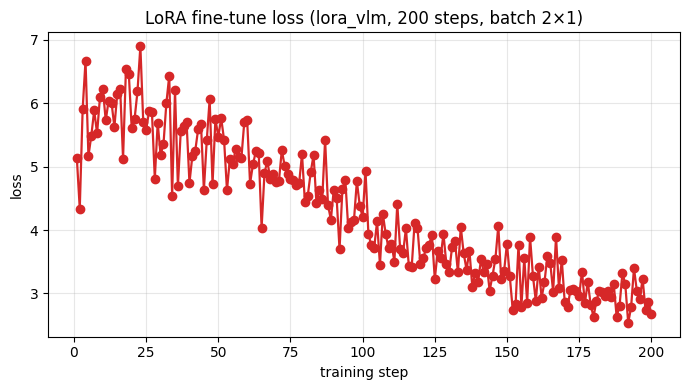

loss: 5.1290 -> 2.6770 over 200 logged step(s)


In [7]:
import shutil

FT_MODE    = os.environ.get("FT_MODE", "lora_vlm")
# Workshop default: just 10 steps to prove the loop end to end. SAVE_FREQ defaults to STEPS,
# so a checkpoint reliably lands at the final step (this is what Step 5 loads). Raise STEPS
# (e.g. 10000) for real training.
STEPS      = 200 # int(os.environ.get("STEPS", "10"))
SAVE_FREQ  = int(os.environ.get("SAVE_FREQ", str(STEPS)))
# Log every step by default so the short workshop run yields a full loss curve (one point per
# step) to plot below; bump for long runs where per-step logging is too chatty.
LOG_FREQ   = int(os.environ.get("LOG_FREQ", "1"))
# Per-GPU batch size: keep small on a single Strix Halo, larger with more GPUs.
BATCH_SIZE = int(os.environ.get("BATCH_SIZE", "2" if N_GPUS == 1 else "8"))
JOB_NAME   = os.environ.get("JOB_NAME", f"mm2_{FT_MODE}_ws")
CKPT_DIR   = os.environ.get("CHECKPOINTS_DIR", "/checkpoints")
OUTPUT_DIR = os.path.join(CKPT_DIR, JOB_NAME)
# The allenai LIBERO dataset ships without LeRobot codebase-version tags; pin a branch.
DATASET_REVISION = os.environ.get("DATASET_REVISION", "main")

# FT_MODE -> --policy.train_mode_vlm : lora (adapters on VLM + trainable action expert),
# freeze (VLM frozen, action expert only), fft (full fine-tune).
MODE_ARGS = {
    "lora_vlm":           ["--policy.train_mode_vlm=lora",   "--policy.action_mode=both"],
    "action_expert_only": ["--policy.train_mode_vlm=freeze", "--policy.action_mode=continuous"],
    "full":               ["--policy.train_mode_vlm=fft",    "--policy.action_mode=both"],
}[FT_MODE]

# LeRobot refuses to write into a non-empty output_dir; clean prior workshop reruns.
if os.path.isdir(OUTPUT_DIR) and os.environ.get("CLEAN_OUTPUT", "1") == "1":
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(CKPT_DIR, exist_ok=True)

print("=" * 63)
print(f" MolmoAct2 fine-tune | base={BASE_CKPT}  mode={FT_MODE}")
print(f"   GPUs(procs)={N_GPUS}  batch/GPU={BATCH_SIZE}  steps={STEPS}  save_freq={SAVE_FREQ}")
print(f"   output_dir={OUTPUT_DIR}")
print("=" * 63)

# The exact accelerate + LeRobot training command, shown inline (no hidden wrapper). The SAME
# command runs single-GPU on Strix Halo and multi-GPU on an Instinct node (num_processes=N_GPUS).
cmd = [
    TRAIN_PY, "-m", "accelerate.commands.launch",
    f"--num_processes={N_GPUS}", "--mixed_precision=bf16",
    "-m", "lerobot.scripts.lerobot_train",
    f"--dataset.repo_id={DATASET_REPO}",
    f"--dataset.revision={DATASET_REVISION}",
    "--dataset.video_backend=pyav",
    "--dataset.image_transforms.enable=true",
    "--policy.type=molmoact2",
    f"--policy.checkpoint_path={BASE_CKPT}",
    "--policy.device=cuda",
    *MODE_ARGS,
    "--policy.chunk_size=10", "--policy.n_action_steps=10",
    "--policy.setup_type=single franka robotic arm in libero",
    "--policy.control_mode=delta end-effector pose",
    '--policy.image_keys=["observation.images.image","observation.images.wrist_image"]',
    "--policy.model_dtype=bfloat16", "--policy.num_flow_timesteps=8",
    "--policy.gradient_checkpointing=true", "--policy.freeze_embedding=true",
    "--policy.normalize_gripper=false", "--policy.enable_knowledge_insulation=false",
    "--policy.push_to_hub=false",
    f"--wandb.enable={os.environ.get('WANDB_ENABLE', 'false')}",
    f"--job_name={JOB_NAME}", f"--output_dir={OUTPUT_DIR}",
    f"--steps={STEPS}", f"--batch_size={BATCH_SIZE}",
    f"--num_workers={os.environ.get('NUM_WORKERS', '4')}",
    f"--log_freq={LOG_FREQ}", f"--eval_freq={STEPS + 1}",
    "--save_checkpoint=true", f"--save_freq={SAVE_FREQ}",
]
loss_pts = run_train(cmd, env=child_env())
print(f"PASS: fine-tune finished; checkpoints under {OUTPUT_DIR}/checkpoints/")

# Loss curve for the run we just did (LeRobot logs one point per --log_freq step). Even a short
# workshop run should trend downward; raise STEPS for a smoother, more convincing curve.
import matplotlib.pyplot as plt  # inline backend -> renders in the notebook, no Agg/subprocess
if len(loss_pts) >= 2:
    steps, losses = zip(*loss_pts)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(steps, losses, marker="o", color="tab:red", lw=1.6)
    ax.set_xlabel("training step"); ax.set_ylabel("loss")
    ax.set_title(f"LoRA fine-tune loss ({FT_MODE}, {STEPS} steps, batch {BATCH_SIZE}×{N_GPUS})")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "finetune_loss.png"), dpi=110)
    plt.show()
    print(f"loss: {losses[0]:.4f} -> {losses[-1]:.4f} over {len(losses)} logged step(s)")
else:
    print(f"(captured {len(loss_pts)} loss point(s) - need >=2 to plot; raise STEPS or lower LOG_FREQ)")

In [9]:
# Locate the checkpoint LeRobot just saved (.../checkpoints/<step>/pretrained_model). Prefer a
# real numbered step over the 'last' symlink; if the short run produced nothing (e.g. it was
# interrupted), fall back to the provided reference checkpoint instead of failing hard.
REFERENCE = os.environ.get("REFERENCE_POLICY", "/checkpoints/reference/pretrained_model")
cands = sorted(glob.glob(os.path.join(OUTPUT_DIR, "checkpoints", "*", "pretrained_model")))
cands = [c for c in cands if os.path.basename(os.path.dirname(c)) != "last"] or cands

if cands:
    POLICY_PATH = cands[-1]
    print("fine-tuned checkpoint (POLICY_PATH):", POLICY_PATH)
elif os.path.isdir(REFERENCE):
    POLICY_PATH = REFERENCE
    print(f"no fine-tune checkpoint under {OUTPUT_DIR}/checkpoints/*; using reference: {POLICY_PATH}")
else:
    raise FileNotFoundError(
        f"no pretrained_model under {OUTPUT_DIR}/checkpoints/* and no reference at {REFERENCE}.\n"
        f"Re-run Step 4 and make sure STEPS >= SAVE_FREQ so a checkpoint is written.")

POLICY_PATH = "/checkpoints/reference/pretrained_model" 

fine-tuned checkpoint (POLICY_PATH): /checkpoints/mm2_lora_vlm_ws/checkpoints/000200/pretrained_model


## 5. Load the LoRA checkpoint on the DROID base -> LIBERO policy (closed-loop eval)

The fine-tune saved a LeRobot-format checkpoint (`.../pretrained_model`): the DROID base config + the trained LoRA adapter weights + the LIBERO normalization/processor stats. Loading it with `--policy.path` reconstructs the runtime LIBERO policy (base + adapter merged at load), with no `norm_tag` needed. Here we run that policy in the LIBERO MuJoCo simulator (headless EGL on the AMD GPU) and report success.

**This is intentionally tiny.** A LIBERO suite has ~10 tasks and the evaluator runs `N_EPISODES` rollouts *per task*, so a whole suite is `N_EPISODES × 10` MuJoCo rollouts - minutes of stepping. For the workshop we pin a **single task** (`--env.task_ids=[TASK_ID]`) and run just a few episodes, so this cell finishes quickly and is only a smoke-number. The **interactive sim (Step 6) is the real demo**; a very short LoRA run won't converge, so use the reference checkpoint (last section) for a strong number and full-suite eval offline.

In [10]:
# Closed-loop LIBERO eval of the checkpoint (headless EGL on the AMD GPU). The saved processor
# + normalization stats are restored from the checkpoint via --policy.path (no norm_tag). The
# exact lerobot-eval command is inline here; a very short LoRA run won't fully converge - use
# the reference checkpoint (last section) for a strong number.
SUITE      = os.environ.get("SUITE", "libero_object")
# A LIBERO suite has ~10 tasks and the evaluator runs `n_episodes` rollouts PER task, so the
# full suite is n_episodes x 10. This is only a quick sanity number (the interactive sim is the
# real demo), so we pin ONE task (TASK_ID) and run a handful of episodes -> ~2-3 rollouts total.
TASK_ID    = os.environ.get("TASK_ID", "3")
N_EPISODES = os.environ.get("N_EPISODES", "3")
SEED       = os.environ.get("SEED", "1000")
RUN_DIR    = os.path.join(OUT_DIR, f"_ft_eval_{SUITE}_t{TASK_ID}_seed{SEED}")
os.makedirs(RUN_DIR, exist_ok=True)

eval_env = child_env(MUJOCO_GL="egl", PYOPENGL_PLATFORM="egl", OMP_NUM_THREADS="1", MKL_NUM_THREADS="1")
cmd = [
    "/opt/train-venv/bin/lerobot-eval",
    f"--policy.path={POLICY_PATH}",
    "--policy.inference_action_mode=continuous",
    "--policy.model_dtype=bfloat16", "--policy.use_amp=true",
    "--policy.enable_inference_cuda_graph=false", "--policy.device=cuda",
    "--policy.per_episode_seed=true", f"--policy.eval_seed={SEED}",
    "--env.type=libero", f"--env.task={SUITE}",
    f"--env.task_ids=[{TASK_ID}]",  # single task -> keep the workshop eval to a few rollouts
    '--env.camera_name_mapping={"agentview_image":"image","robot0_eye_in_hand_image":"wrist_image"}',
    "--eval.batch_size=1", f"--eval.n_episodes={N_EPISODES}",
    f"--seed={SEED}", f"--output_dir={os.path.join(RUN_DIR, 'run')}",
]
print(f"quick closed-loop eval: suite={SUITE} task_id={TASK_ID}  ->  {N_EPISODES} rollout(s) total\n")
run_cmd(cmd, env=eval_env)
print(f"PASS: eval artifacts in {RUN_DIR}")

quick closed-loop eval: suite=libero_object task_id=3  ->  3 rollout(s) total

$ /opt/train-venv/bin/lerobot-eval --policy.path=/checkpoints/reference/pretrained_model --policy.inference_action_mode=continuous --policy.model_dtype=bfloat16 --policy.use_amp=true --policy.enable_inference_cuda_graph=false --policy.device=cuda --policy.per_episode_seed=true --policy.eval_seed=1000 --env.type=libero --env.task=libero_object --env.task_ids=[3] --env.camera_name_mapping={"agentview_image":"image","robot0_eye_in_hand_image":"wrist_image"} --eval.batch_size=1 --eval.n_episodes=3 --seed=1000 --output_dir=/outputs/_ft_eval_libero_object_t3_seed1000/run

WARNING 2026-07-18 02:09:32 figs/eval.py:69 No job name provided, using 'libero_molmoact2' as job name.
INFO 2026-07-18 02:09:32 bot_eval.py:529 {'env': {'camera_name': 'agentview_image,robot0_eye_in_hand_image',
         'camera_name_mapping': {'agentview_image': 'image',
                                 'robot0_eye_in_hand_image': 'wrist_image'

## 6. Interactive sim (synchronous chunk replay)

Launches the browser-based LIBERO sim on the fine-tuned checkpoint in **synchronous** mode: the simulator holds still while the policy plans an action chunk, then executes that whole chunk before planning the next one (plan -> act -> plan). There is no real-time chunk blending, so what you see is exactly what the policy predicts - the cleanest, most faithful view of a checkpoint's behavior.

We use the synchronous server here (rather than the RTC real-time-blending variant) on purpose: a **short workshop LoRA run isn't fully consolidated**, and the real-time stitcher's plan-ahead blending gets jittery/buggy on an under-trained policy. Synchronous replay avoids that and is the right tool for inspecting a fresh checkpoint. (The reference checkpoint in the last section behaves well here too.)

It runs in the background; open the URL, type an instruction, and watch the policy act.

- Local box: open **http://localhost:8080**
- Remote/headless box: forward first -> `ssh -L 8080:localhost:8080 <host>`, then open http://localhost:8080

Re-run the cell to restart the server (e.g. after training a new checkpoint).

In [11]:
import itertools
PORT   = os.environ.get("PORT", "8080")
SERVER = os.path.join(RYZERS, "interactive_server_ft.py")  # synchronous chunk-replay server

# Stop any previous server instance we started from this notebook.
try:
    if _sim and _sim.poll() is None:
        _sim.send_signal(signal.SIGINT); _sim.wait(timeout=5)
except NameError:
    pass
except Exception:
    pass

# Launch the synchronous sim server directly (env inline, no wrapper script): plan -> execute the
# whole chunk -> replan. No real-time blending, so an under-trained checkpoint stays stable.
sim_env = child_env(
    POLICY_PATH=POLICY_PATH, PORT=PORT,
    SUITE=os.environ.get("SUITE", "libero_object"),
    TASK_ID=os.environ.get("TASK_ID", "3"),
    SEED=os.environ.get("SEED", "1000"),
    NUM_STEPS=os.environ.get("NUM_STEPS", "10"),
)
_sim = subprocess.Popen([TRAIN_PY, SERVER], env=sim_env,
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
print(f"Synchronous interactive sim starting on http://localhost:{PORT}  (suite={sim_env['SUITE']} task_id={sim_env['TASK_ID']})")
print(f"Remote box: ssh -L {PORT}:localhost:{PORT} <host>  then open http://localhost:{PORT}\n")
# Stream a few lines so you can see it come up (interrupt the cell to stop streaming; the
# server keeps running in the background). Re-run this cell to restart it.
for line in itertools.islice(_sim.stdout, 60):
    if any(tok in line for tok in _NOISE):
        continue
    print(line, end="", flush=True)

Synchronous interactive sim starting on http://localhost:8080  (suite=libero_object task_id=3)
Remote box: ssh -L 8080:localhost:8080 <host>  then open http://localhost:8080

interactive (fine-tuned) demo on http://localhost:8080  (remote box: ssh -L 8080:localhost:8080 <host>)
Loading weights from local directory
[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /opt/venv/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)
Creating LIBERO envs | suites=['libero_object'] | n_envs(per task)=1 | init_states=True
Restricting to task_ids=[3]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Built vec env | suite=libero_object | task_id=3 | n_envs=1
Local assets not found. Downloading from HuggingFace Hub...
Assets already downloaded at /root/.cache/libero/assets

Running rollout with at most 280 steps:  11%|█         | 3

## Reference checkpoint (compelling demo without waiting for a long train)

A short LoRA run demonstrates the *pipeline* but will not fully converge. For a strong sim demo, point `POLICY_PATH` at the provided longer-trained reference checkpoint (organizers supply the path / Hub repo; on this box it is placed under `/checkpoints/reference/pretrained_model`), then re-run sections 5-6:

```python
POLICY_PATH = "/checkpoints/reference/pretrained_model"   # or a Hub repo id
```

Notes:
- Weights, images and large videos live only on the remote machine (workspace policy). Small eval artifacts land under `/outputs`.
- To train for real, raise `STEPS` (e.g. 10000) and, on a multi-GPU Instinct node, `BATCH_SIZE`.